Here we provide details of the derivation/verification of the solution to the continuum
$$
-\nabla ^2 p = 0
$$
with boundary conditions similar to those of the grid graph problem, where flow is injected into the grid through the centre node on the bottom layer and removed through the center node on the top layer.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.integrate

#### Integration of ln (r) along real half-axis

First we verify the implementation of integral( ln (x - x0)  d(x0)) from -a to a.

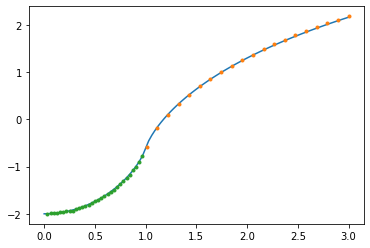

In [2]:
a = 1.0

def f(x):
  tm = np.abs(np.abs(x) - a)
  tp = np.abs(np.abs(x) + a)
  s1 = np.zeros_like(tm)
  np.log(tm, out=s1, where=tm>0)
  s1 = tm * (s1 - 1)
  s2 = tp * (np.log(tp) - 1)
  return np.where(np.abs(x) < a, s2 + s1, s2 - s1)

x_range = np.linspace(0, 3*a, 100)
plt.plot(x_range, f(x_range))

''' Compare to numerical integration on the exterior '''
x_range_ext = np.linspace(1.01, 3.0, 20)[:, np.newaxis]
integration_range = np.linspace(-1, 1, 100)
dx = integration_range[1] - integration_range[0]
empirical_f = np.log(x_range_ext - integration_range).sum(axis=1) * dx
plt.plot(x_range_ext, empirical_f, '.')

''' Compare to numerical integration in the interior '''
x_range_int = np.linspace(0.0, 1.0, 33)[1:-1, np.newaxis]
integration_range = np.linspace(-1, 1, 232)
dx = integration_range[1] - integration_range[0]
empirical_f = np.log(np.abs(x_range_int - integration_range)).sum(axis=1) * dx
plt.plot(x_range_int, empirical_f, '.')


#### Potential calculation based on Green's representation for semi-infinite 2D

Here we consider a semi-infinite domain $(-\infty, +\infty) \times [0, +\infty)$, with Neumann boundary data prescribed on the $x$-axis.

For Neumann data $\partial u/\partial n = 1.0$ for $-a < x < +a$ and zero everywhere else, Green's representation implies that
$$
\left. \frac{1}{2} u \right|_\Gamma = -\frac{1}{2 \pi} \int_{-a}^{a} \ln (x - x_0) dx_0,
$$
since any term dependent on $(\partial/\partial n) G(x - x_0)$ vanishes on the boundary.

Text(0, 0.5, '$u$ on boundary')

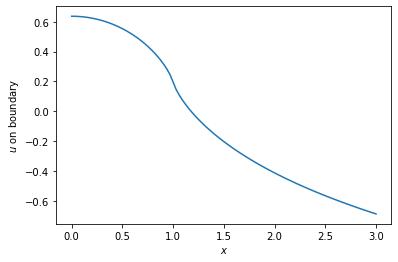

In [3]:
def u_bdry_demo(x):
  ''' u along boundary '''
  return -1.0/(np.pi) * f(x)

plt.plot(x_range, u_bdry_demo(x_range))
plt.xlabel("$x$")
plt.ylabel("$u$ on boundary")

### Method of images for the field solution $u(x,t;a,L_z)$

We construct the solution to the Poisson problem
$$
-\nabla^2 u = 0
$$
for a slab $(-\infty, +\infty) \times [0, L_z]$ subject to Neumann boundary conditions. We set the Neumann data to zero everywhere, except for $x \in [-a ,a]$, where we set $\partial u / \partial z = -1$.

To approach this problem, we use an image expansion of the half-space solution to the Poisson problem in $(-\infty, +\infty) \times [0, +\infty)$ with the same Neumann data on the $x$-axis. By alternating the sign and reflecting the solution, we can construct a solution that satisfies the Neumann data at both $z = 0$ and $z = L_z$.

### Various representations of the single-layer and double-layer potential

The half-space solution is given by Green's representation. 
$$
u (x, z) = \int_{-\infty}^{\infty} G(x - x_0, z) \frac{\partial u}{\partial n} (x_0, 0)~dx_0 - \int_{-\infty}^{\infty} \frac{\partial G}{\partial n} (x - x_0, z) u (x_0, 0)~dx_0,
$$
where the first and second terms on the right hand side are called the single- and double-layer potentials, respectively. Note that the factor of $1/2$ is only present when evaluating exactly on the boundary.

We use this representation to compute the solution in the interior of the domain. In the following, we implement the single-layer potential and double-layer potential in several ways.

#### Single-layer potential

The single layer potential is
$$
\int_\Gamma G \frac{\partial u}{\partial n} d\gamma,
$$
and for piecewise constant Neumann data, this integral amounts to integrating $\log(r)$. This can be done in terms of standard functions.

In [4]:
def u_bdry(x, a):
  ''' u along boundary '''
  tm = np.abs(np.abs(x) - a)
  tp = np.abs(np.abs(x) + a)
  s1 = np.zeros_like(tm)
  np.log(tm, out=s1, where=tm>0)
  s1 = tm * (s1 - 1)
  s2 = tp * (np.log(tp) - 1)
  return -1.0/np.pi * np.where(np.abs(x) < a, s2 + s1, s2 - s1)

def G(x, z, x0, z0):
  ''' Fundamental Poisson solution '''
  return -0.25 / np.pi * np.log((x-x0)**2 + (z-z0)**2)

def dGdn(x, z, x0, z0, normal_sign):
  ''' Normal derivative of G(x0, z0; x, z) with respect to (x0, z0) '''
  # Compute distance and direction-cosine
  r = np.sqrt((x-x0)**2 + (z-z0)**2)
  dir_cos = (z - z0) / r
  return -0.5 * normal_sign / (np.pi * r) * dir_cos

def SL_integral_indef(x, z, x0, z0):
  ''' Indefinite integral version of the single-layer potential for unit Neumann data. '''
  dx = x - x0
  dz = z - z0
  temp = dx * np.log(dx*dx + dz*dz) + 2 * dz * np.arctan(dx/dz) + 2* x0
  return 0.25 / np.pi * temp

def SL_integral(x, z, z0, a):
  ''' Single-layer potential (integration from -a to a).
  Returns the solution u on the boundary when z = z0. '''
  dz = z - z0
  # Compute 1 / dz with no warnings
  dz_inv = np.zeros_like(dz)
  np.divide(1.0, dz, where=dz != 0, out=dz_inv)
  temp = (x - a) * np.log((x - a)*(x - a) + dz*dz) \
    - (x + a) * np.log((x + a)*(x + a) + dz*dz) \
    + 2 * dz * (np.arctan((x - a) * dz_inv) - np.arctan((x + a) * dz_inv)) + 4 * a
  # Use u bdry solution for limit dz = 0
  return np.where(dz != 0,  0.25 / np.pi * temp, 0.5 * u_bdry(x, a))

Compare explicit integral to numerical quadrature in [-a, a]


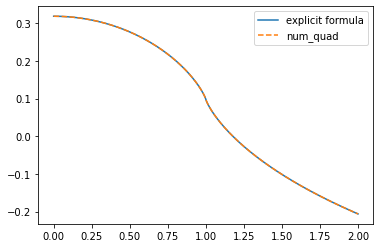

In [5]:
# Verify exact integration

# Evaluate with closed form
x_test_range = np.linspace(0,2,1000)
z_test_scalar = 0.0001 * a
z_test_range = np.full_like(x_test_range, z_test_scalar)
SL1 = SL_integral(x_test_range, z_test_range, 0.0, a)

# Evaluate numerically
SL2 = np.zeros_like(SL1)
for i, _x in enumerate(x_test_range):
  SL2[i] = scipy.integrate.quad(lambda x0: G(_x, z_test_scalar, x0, 0.0), -a, a)[0]

plt.plot(x_test_range, SL1, label="explicit formula")
plt.plot(x_test_range, SL2, '--', label="num_quad")
plt.legend()
print("Compare explicit integral to numerical quadrature in [-a, a]")

#### Double-layer potential

The double-layer potential is
$$
\int_\Gamma \frac{\partial G}{\partial n} u~d\gamma,
$$
and for piecewise constant Neumann data, $u$ is non-constant. This integral is more complicated to evaluate, and cannot be expressed in terms of standard functions.

In this part, we offer numerical solution (quadrature) and representation through the dilogarithm, which is defined by
$$
\mathrm{Li}_2(z) = - \int_0^z t^{-1} \ln(1 - t)~dt
$$
for most of the complex plane; see for example DLMF.


In [6]:
''' Scaled double layer potential integrands
These functions have the leading constant removed for simplicity.
'''

def linearithm(z):
  ''' Returns L(z) = z log |z| with limit L(0) = 0. '''
  out = np.zeros_like(z)
  np.log(np.abs(z), where=(z != 0), out=out)
  return z * out

def DL_integrand(x, x0, z, z0, a, normal_sign):
  ''' Integrand for the scaled double-layer potential.
  The sign of normal_sign is +1 if the normal is aligned with the +z-direction,
  and is otherwise -1. '''
  r2 = (x - x0) ** 2 + (z - z0)**2
  return 2 * normal_sign * (z - z0) / (4*np.pi*np.pi) *(
    linearithm(np.abs(x0) + a) - linearithm(np.abs(x0) - a) - 2 * a
  ) / r2 

def DL_integrand_powerpart(x, x0, z, z0, a):
  ''' 1/r^2 part of double layer integrand DL_integrand.
  This part can be explicitly integrated from -infty to +infty to value pi/2. '''
  tm = (np.abs(x) - a)
  tp = (np.abs(x) + a)
  s1 = tm * (- 1)
  s2 = tp * (- 1)
  return 2 * (s2 - s1) / ((x - x0)**2 + (z - z0)**2)

def DL_integrand_logpart(x, x0, z, z0, a, normal_sign):
  ''' Double layer integrand as in DL_integrand, with 1/r^2 part removed. '''
  r2 = (x - x0) ** 2 + (z - z0)**2
  return 2 * normal_sign * (z - z0) / (4*np.pi*np.pi) *(
    linearithm(np.abs(x0) + a) - linearithm(np.abs(x0) - a) #- 2 * a
  ) / r2

def DL_integrand_simple(x, z, x0):
  ''' Simple implementation of complete DL integrand '''
  return dGdn(x, z, x0, 0, 1.0) * u_bdry(x0, a)

In [7]:
def DL_integral(x, z, z0, a, normal_sign):
  ''' Compute double layer potential by numerical quadrature of DL_integrand
  Slightly faster than numerical quadrature of DL_integrand_simple. '''
  _integrand = lambda x0: DL_integrand(x, x0, z, z0, a, normal_sign)
  return scipy.integrate.quad(_integrand, -np.inf, np.inf)[0]

def DL_integral_2(x, z, z0, a, normal_sign):
  ''' As DL_integral, but evaluating the integral of the powerpart explicitly. '''
  _integrand = lambda x0: DL_integrand_logpart(x, x0, z, z0, a, normal_sign)
  return scipy.integrate.quad(_integrand, -np.inf, np.inf)[0] - 2 * a * normal_sign / (2 * np.pi)

In [8]:
''' Double-layer potential using dilogarithm '''

from scipy.special import spence

# Alias dilogarithm, using 1-z convention
dilog = lambda z: spence(1 - z)

def I(x, a, b, c):
  ''' Indefinite integral of
    x * log(x+a) / ((x - c)^-2  + b^-2 )
  using the dilogarithm (spence function). For real arguments, the output
  is complex with zero imaginary component.
  '''
  if np.isclose(x + a, 0.0):
    return 0.0
  return (
    np.log(a + x) * (
      (b + 1j * c) * np.log(1 - (a + x)/(a - 1j * b + c))
      + (b - 1j * c) * np.log(1 - (a + x)/(a + 1j * b + c)))
    + (b + 1j * c) * dilog((a + x)/(a - 1j * b + c))
    + (b - 1j * c) * dilog((a + x)/(a + 1j * b + c))) / (2 * b)

def J(x, a, b, c):
  ''' Indefinite integral of
    log(x+a) / ((x - c)^-2  + b^-2 )
  using the dilogarithm (spence function). For real arguments, the output
  is complex with zero imaginary component.
  '''
  z = a + c + 1j * b
  zc = a + c - 1j * b
  if np.isclose(x + a, 0.0):
    # print("A")
    return 0.0
  return (
    np.log(a + x) * (
      np.log((-x + c + 1j * b) / z)
      - np.log((-x + c - 1j * b) / zc))
    - dilog((a + x)/zc)
    + dilog((a + x)/z)
    ) /(2j * b)

def IpaJ(x, a, b, c):
  ''' Optimized I + a*J. '''
  z = c + a + 1j * b
  zc = c + a - 1j * b
  return ( # IpaJ
    np.log(a + x) * (z * np.log(1 - (a + x)/z) - zc * np.log(1 - (a + x)/zc))
    + z * dilog((a + x)/z) - zc * dilog((a + x)/zc)
  ) / (2j * b)

def ImaJ(x, a, b, c):
  ''' Optimized I - a*J. Warning: if -a is passed as arg `a`, this is equivalent
  to I - (-a) * J. Typically only IpaJ is needed. '''
  z = c + a + 1j * b
  zc = c + a - 1j * b
  return (
    np.log(a + x) * (
      + ((c-a) + 1j*b) * np.log(1 - (a + x)/z)
      - ((c-a) - 1j*b) * np.log(1 - (a + x)/zc))
    + ((c-a) + 1j*b) * dilog((a + x)/z)
    - ((c-a) - 1j*b) * dilog((a + x)/zc)
  ) / (2j * b)
  
# For I + a*J, the return value is equivalent to:
# (np.log(a + x) * (
#       (b + 1j * (a + c)) * np.log(1 - (a + x)/zc)
#     + (b - 1j * (a + c)) * np.log(1 - (a + x)/z)) \
#     + (b + 1j * (a + c)) * dilog((a + x)/zc) \
#     + (b - 1j * (a + c)) * dilog((a + x)/z) \
#   ) / (2 * b)

In [9]:
''' Numerical verification dilog-based integral '''

# Large number
x_inf = 1e5
# Test values
a = 1.0
z = 0.1
z0 = 0.0
x = 0.5

# Numerical integration of both terms, in intervals between which absolute value changes behavior
p1_num = scipy.integrate.quad(lambda x0: (-x0 + a) * np.log(-x0 + a) / ((x - x0)**2 + (z - z0)**2), -x_inf, 0)
p2_num = scipy.integrate.quad(lambda x0: (x0 + a) * np.log(x0 + a) / ((x - x0)**2 + (z - z0)**2), 0, x_inf)
p3_num = scipy.integrate.quad(lambda x0: -(np.abs(x0) - a) \
  * np.log(np.abs(np.abs(x0) - a)) / ((x - x0)**2 + (z - z0)**2), -x_inf, -a)
p4_num = scipy.integrate.quad(lambda x0: -(np.abs(x0) - a) \
  * np.log(np.abs(np.abs(x0) - a)) / ((x - x0)**2 + (z - z0)**2), -a, 0)
p5_num = scipy.integrate.quad(lambda x0: -(np.abs(x0) - a) \
  * np.log(np.abs(np.abs(x0) - a)) / ((x - x0)**2 + (z - z0)**2), 0, a)
p6_num = scipy.integrate.quad(lambda x0: -(np.abs(x0) - a) \
  * np.log(np.abs(np.abs(x0) - a)) / ((x - x0)**2 + (z - z0)**2), a, x_inf)

# Integrate (|x| + a) * log ||x| + a| / r^2 from -inf to 0 then 0 to inf, 
p1 = I(x_inf, a, z - z0, -x)   - I(0, a, z - z0, -x)  + a * J(x_inf, a, z - z0, -x)  - a * J(0, a, z - z0, -x)
p2 = I(x_inf, a, z - z0, x)    - I(0, a, z - z0, x)   + a * J(x_inf, a, z - z0, x)   - a * J(0, a, z - z0, x)
# Integrate -(|x| - a) * log ||x| - a| / r^2 from -inf to -a, -a to 0, 0 to a, a to inf
p3 = -I(x_inf, -a, z - z0, -x) - I(a, -a, z - z0, -x) + a * J(x_inf, -a, z - z0, -x) - a * J(a, -a, z - z0, -x)
p4 = I(0, a, z - z0, x)        - I(-a, a, z - z0, x)  + a * J(0, a, z - z0, x)       - a * J(-a, a, z - z0, x)
p5 = I(0, a, z - z0, -x)       - I(-a, a, z - z0, -x) + a * J(0, a, z - z0, -x)      - a * J(-a, a, z - z0, -x)
p6 = -I(x_inf, -a, z - z0, x)  - I(a, -a, z - z0, x)  + a * J(x_inf, -a, z - z0, x)  - a * J(a, -a, z - z0, x)

((p1_num[0], p1,),
 (p2_num[0], p2,),
 (p3_num[0], p3,),
 (p4_num[0], p4,),
 (p5_num[0], p5,),
 (p6_num[0], p6,),)

((67.54048132667512, (67.54048132667515+0j)),
 (88.33959002842744, (88.33959002842735+0j)),
 (-64.14108572118272, (-64.14108572118435+0j)),
 (-0.26177187242887273, (-0.26177187242887356+0j)),
 (-8.719502474091957, (-8.719502474091984+0j)),
 (-65.08622478345453, (-65.08622478345485-0j)))

In [10]:
mat = np.array(
    [[I(x_inf, a, z - z0, -x),   -I(0, a, z - z0, -x),  a * J(x_inf, a, z - z0, -x),  -a * J(0, a, z - z0, -x)],
     [I(x_inf, a, z - z0, x),    -I(0, a, z - z0, x),   a * J(x_inf, a, z - z0, x),   -a * J(0, a, z - z0, x) ],
     [-I(x_inf, -a, z - z0, -x), 0.0,                   a * J(x_inf, -a, z - z0, -x), 0.0                    ],
     [I(0, a, z - z0, x),        0.0,                   a * J(0, a, z - z0, x),       0.0                    ],
     [I(0, a, z - z0, -x),       0.0,                   a * J(0, a, z - z0, -x),      0.0                    ],
     [-I(x_inf, -a, z - z0, x),  0.0,                   a * J(x_inf, -a, z - z0, x),  0.0                    ],])
print("Full table of terms; each row summed represents a piece of the definite "
      + "integral. Note the cancelation between some terms and zero imaginary part.")
print(mat)

Full table of terms; each row summed represents a piece of the definite integral. Note the cancelation between some terms and zero imaginary part.
[[ 78.65135558+0.j -12.49196181-0.j -19.83037673-0.j  21.21146428+0.j]
 [ 75.54160944+0.j  -0.46371786-0.j  12.53620872+0.j   0.72548973+0.j]
 [-64.41234728-0.j   0.        +0.j   0.27126156+0.j   0.        +0.j]
 [  0.46371786+0.j   0.        +0.j  -0.72548973-0.j   0.        +0.j]
 [ 12.49196181+0.j   0.        +0.j -21.21146428-0.j   0.        +0.j]
 [-63.75656787-0.j   0.        +0.j  -1.32965691-0.j   0.        +0.j]]


In [11]:
mat = np.array(
    [[I(x_inf, a, z - z0, -x),   -0.0, a * J(x_inf, a, z - z0, -x),  -0.0],   # (|x| + a) * log ||x| + a| from -inf to 0
     [I(x_inf, a, z - z0, x),    -0.0, a * J(x_inf, a, z - z0, x),   -0.0],   # (|x| + a) * log ||x| + a| from 0 to inf
     [-I(x_inf, -a, z - z0, -x), 0.0,  a * J(x_inf, -a, z - z0, -x), 0.0 ],   # (|x| - a) * log ||x| - a| from -inf to -a
     [0.0,                       0.0,  0.0,                          0.0 ],   
     [0.0,                       0.0,  0.0,                          0.0 ],
     [-I(x_inf, -a, z - z0, x),  0.0,  a * J(x_inf, -a, z - z0, x),  0.0 ],]) # (|x| - a) * log ||x| - a| from a to inf
print("Table of terms showing canceled terms as zeros.")
print(mat.real)

Table of terms showing canceled terms as zeros.
[[ 78.65135558  -0.         -19.83037673  -0.        ]
 [ 75.54160944  -0.          12.53620872  -0.        ]
 [-64.41234728   0.           0.27126156   0.        ]
 [  0.           0.           0.           0.        ]
 [  0.           0.           0.           0.        ]
 [-63.75656787   0.          -1.32965691   0.        ]]


In [12]:
def DL_int(x, z, z0, a, normal_sign, x_inf=1e12):
  ''' Double-layer potential evaluated using dilogarithm.
  Due to symmetry, only several terms need to be accounted for. Terms
  depending on the antiderivative evaluated at a cancel. '''
  summed = (IpaJ(x_inf, a, z - z0, -x) + IpaJ(x_inf, a, z - z0, x)
          - IpaJ(x_inf, -a, z - z0, -x) - IpaJ(x_inf, -a, z - z0, x))
  return 2 * (normal_sign * (z - z0) / (4 * np.pi * np.pi)) * summed.real - 2 * a * normal_sign / (2 * np.pi)

#### Double layer potential computation intercomparison

To verify the implementation, we cross-compare:
  1. Integration using special function `dilog`
  2. Numerical integration with explicit formulas for dG/dn and u
  3. Numerical integration with simplified formula for product dG/dn * u
  4. Numerical integration as 3, but with one easy term integrated explicitly

In [13]:
x = 0.1231
z = .001
z0 = 0.0
a = 0.2234
normal_sign = 1.0

methods = [
  lambda : DL_int(x, z, 0.0, a, 1.0), \
  lambda: scipy.integrate.quad(lambda x0: DL_integrand_simple(x, z, x0), -np.inf, np.inf)[0], \
  lambda: scipy.integrate.quad(lambda x0: DL_integrand(x, x0, z, 0.0, a, 1.0), -np.inf, np.inf)[0], \
  lambda: DL_integral_2(x, z, 0.0, a, 1.0)
]

results = np.array([method() for method in methods])

print("Results:")
print(results)
print("Difference from mean:")
print(results - results.mean())


Results:
[-0.16576934 -0.16576934 -0.16576934 -0.16576934]
Difference from mean:
[-4.38627468e-11  1.46208601e-11  1.46209433e-11  1.46209989e-11]


dilog: Explicit integration using dilogarithm
numquadsimple: Numerical quadrature using simple integrand representation
numquad: Numerical quadrature using standard integrand representation
numquadfac: Numerical quadrature using standard integrand representation + explicitly integrating 1/r^2 part


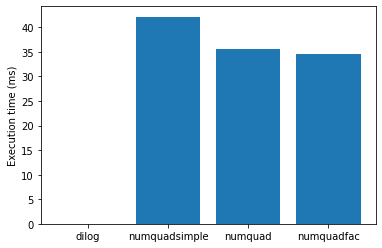

In [14]:
import timeit
timing = np.array([timeit.timeit(method, number=10)/10 for method in methods])

plt.bar(["dilog", "numquadsimple", "numquad", "numquadfac"], timing*1e3)
plt.ylabel("Execution time (ms)")
print("dilog: Explicit integration using dilogarithm")
print("numquadsimple: Numerical quadrature using simple integrand representation")
print("numquad: Numerical quadrature using standard integrand representation")
print("numquadfac: Numerical quadrature using standard integrand representation + explicitly integrating 1/r^2 part")

Left: interior solution limit vs. boundary value
Right: correspondance SL = -DL near boundary
Here z = 1e-08, close to zero.


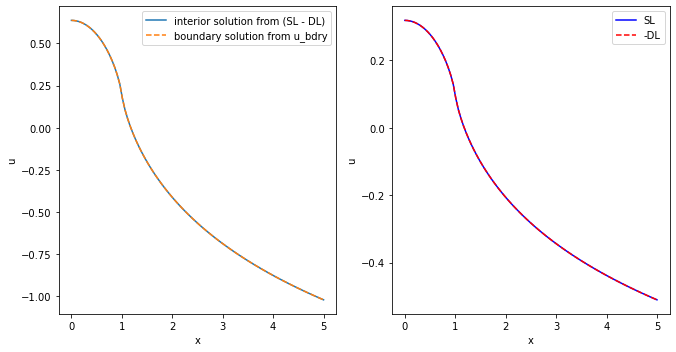

In [15]:
''' Consistency check: limiting value in the domain vs. boundary value

On the boundary, DL == 0 exactly.
In the limit z -> 0, DL should have value equal to SL to account for the factor
of 0.5 that appears exactly at the boundary.
'''

x_range = np.linspace(0,5,100)
a = 1.0
z0 = 0.0
eps = 1e-8
z_range = 0.0*x_range + eps

# Compute potentials
DL = DL_int(x_range, z_range, z0, a=1.0, normal_sign=1.0)
SL = SL_integral(x_range, z_range, z0, a)

plt.figure(figsize=(9.5,5))
plt.subplot(1,2,1)
plt.plot(x_range, (SL - DL), label="interior solution from (SL - DL)")
plt.plot(x_range, u_bdry(x_range, a), '--', label="boundary solution from u_bdry")
plt.xlabel("x")
plt.ylabel("u")
plt.legend()

plt.subplot(1,2,2)
plt.plot(x_range, SL, 'b', label="SL")
plt.plot(x_range, -DL, 'r--', label="-DL")
plt.xlabel("x")
plt.ylabel("u")
plt.legend()

plt.tight_layout()
print("Left: interior solution limit vs. boundary value")
print("Right: correspondance SL = -DL near boundary")
print(f"Here z = {eps}, close to zero.")

Indeed SL and DL are the same function

9.71445146547012e-15

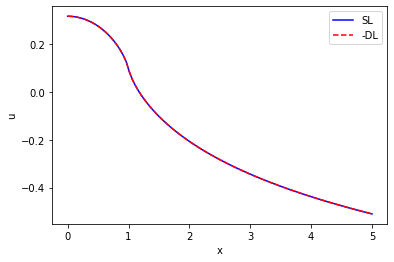

In [16]:
x_range = np.linspace(0,5,100)
a = 1.0
z0 = 0.0
eps = 1e-8
z_range = np.full_like(x_range, 0.00001)

# Compute potentials
DL = DL_int(x_range, z_range, z0, a=a, normal_sign=1.0)
SL = SL_integral(x_range, z_range, z0, a=a)

plt.plot(x_range, SL, 'b', label="SL")
plt.plot(x_range, -DL, 'r--', label="-DL")
plt.xlabel("x")
plt.ylabel("u")
plt.legend()

np.abs(SL + DL).max()

Here we check the boundary condition is satisfied by estimating the normal derivative at the boundary.

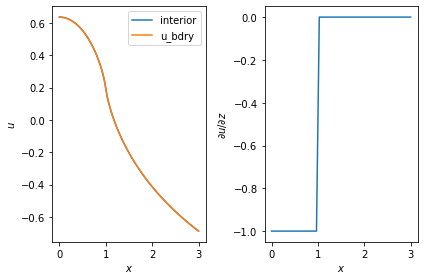

In [17]:
''' Aperture solution in half-space '''
z0 = 0.0
z = 0.5
L_z = 2.0
a = 1.0

x_range = np.linspace(0.0,3*a,100)
eps_z = 1e-7
z_range = np.full_like(x_range, eps_z)

u_line = SL_integral(x_range, z_range, 0.0, a) - DL_int(x_range, z_range, 0.0, a, 1.0, x_inf=x_inf)
u_gamm = u_bdry(x_range, a)

plt.subplot(1,2,1)
plt.plot(x_range, u_line, label="interior")
plt.plot(x_range, u_gamm, label="u_bdry")
plt.xlabel(r"$x$")
plt.ylabel(r"$u$")
plt.legend()
plt.subplot(1,2,2)
plt.plot(x_range, (u_line - u_gamm) / eps_z)
plt.xlabel(r"$x$")
plt.ylabel(r"$\partial u / \partial z$")

plt.tight_layout()

Here we take the single-layer-defined solution in half-space and use an image expansion to compute the slab solution $U$.

In [18]:
def U(x, z, num_images:int, a=1.0, L_z=10.0):
  u = np.zeros(x.shape)
  next_sign = 1.0
  for img_idx in range(num_images):
    u += 2.0 * next_sign * ( # Factor of 2 for SL - DL, where DL == -SL
      SL_integral(x, z, (-img_idx)*L_z, a)
      - SL_integral(x, z, (img_idx+1)*L_z, a))
    next_sign *= -1.0   
  return u

Slab solution for potential:


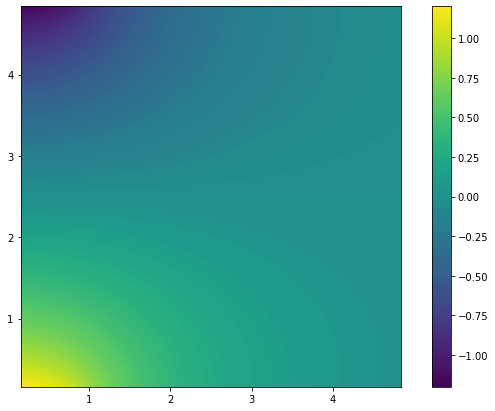

In [19]:
''' Plot slab solution '''
L_z = 5.0
num_images = 10

x_viz_range = np.linspace(0, L_z, 32)[1:-1]
z_viz_range = np.linspace(0, L_z, 32)[1:-1]
mg_x, mg_z = np.meshgrid(x_viz_range, z_viz_range)

mg_u = U(mg_x, mg_z, num_images, a=1.0, L_z=L_z)

plt.figure(figsize=(11,7))
plt.contourf(mg_x, mg_z, mg_u, levels=100)
plt.colorbar()
plt.gca().set_aspect("equal")
print("Slab solution for potential:")

Potential difference scaled by a for values of a in list:
[0.1        0.03162278 0.01       0.00316228 0.001      0.00031623
 0.0001    ]


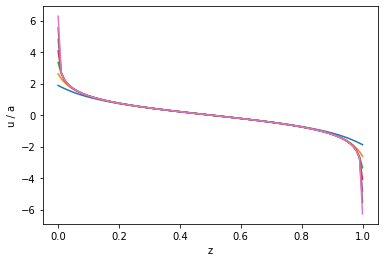

In [20]:
''' Centerline potential for varying a (length scale of ``current inlet") '''

L_z = 1.0
N_z = 100
a = 0.1
z_axis = np.linspace(0, L_z, N_z+2)
x_vals = np.zeros_like(z_axis)
num_images = 5
a_range = L_z * np.logspace(-4, -1, 7)[::-1]

for a in a_range:
  u = U(x_vals, z_axis, num_images, a=a, L_z=L_z)
  plt.plot(z_axis, u / a, '-')

plt.ylabel("u / a")
plt.xlabel("z")
print("Potential difference scaled by a for values of a in list:")
print(a_range)

Finally, we use the image-expansion slab solution to estimate the effective conductivity between the bottom and top boundaries.

We estimate the conductivity $\Phi$ according to
$$
\frac{1}{\Phi} = \frac{1}{(2a)^2} \int_{-a}^{a} \left(u(x, 0.0) - u(x, L_z) \right) dx 
$$

a/L = 0.03333333333333333
Average conductivity = 0.4209046361635568


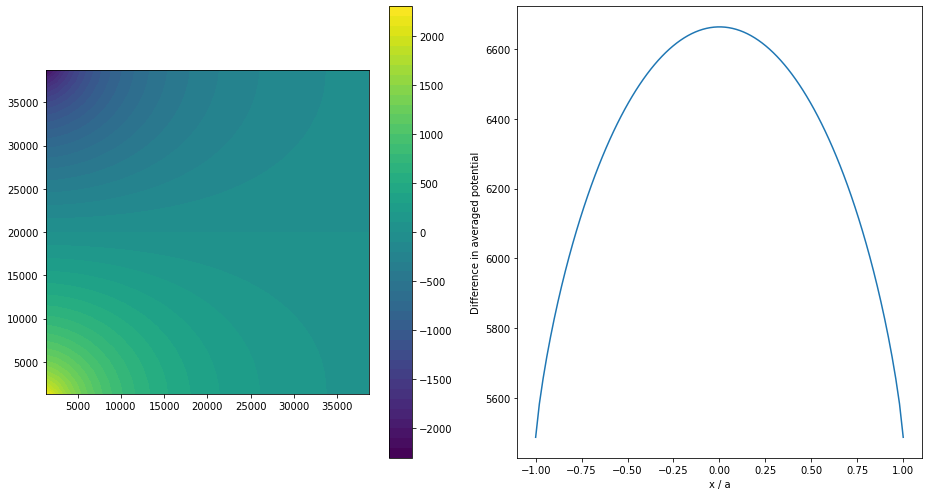

In [21]:
# Specific calculation
L_z = 40000
N = 30
eps = 1e-7
num_images = 20
N_sample = 100
# Compute finite aperture
a = L_z / N

# Evaluate field for plotting
x_viz_range = np.linspace(0, L_z, 32)[1:-1]
z_viz_range = np.linspace(0, L_z, 32)[1:-1]
mg_x, mg_z = np.meshgrid(x_viz_range, z_viz_range)

mg_u = U(mg_x, mg_z, num_images, a=a, L_z=L_z) # + U(mg_x - 2 * L_z, mg_z, 10, a=a, L_z=L_z)

plt.figure(figsize=(13,7))
plt.subplot(1,2,1)
plt.contourf(mg_x, mg_z, mg_u, levels=50)
plt.colorbar()
plt.gca().set_aspect("equal")

# Use symmetry to compute potential difference between boundaries; average over aperture
x_vec_on_bdry = np.linspace(-a, a, N_sample)
z_vec_on_bdry = eps * L_z * np.ones_like(x_vec_on_bdry)
# Build trapezoid quadrature covector
integ_vec = np.ones_like(x_vec_on_bdry) * (x_vec_on_bdry[1] - x_vec_on_bdry[0])
integ_vec[0] *= 0.5
integ_vec[-1] *= 0.5

# Evaluate potential diff
u_terminals_in = U(x_vec_on_bdry, z_vec_on_bdry, num_images, a=a, L_z=L_z)
u_terminals_out = U(x_vec_on_bdry, L_z - z_vec_on_bdry, num_images, a=a, L_z=L_z)
potential_diff = (u_terminals_in - u_terminals_out)
# Compute average
V_avg = np.dot(integ_vec, potential_diff) / (2 * a)

plt.subplot(1,2,2)
plt.plot(x_vec_on_bdry/a, potential_diff)
plt.xlabel("x / a")
plt.ylabel("Difference in averaged potential")

plt.tight_layout()

print(f"a/L = {a/L_z}")
print(f"Average conductivity = {(2 * a / V_avg)}")

To compare to the discrete graph conductivity, note that in the continuum case, we prescribe a unit current density, while in the discrete case, we prescribe a unit total current. To compare to the discrete values, we obtain the net current
$$
I = (2a) \cdot i = \frac{L_z}{N-1} \cdot i.
$$
We are interested in the potential difference per total current, which relates to the potential difference per unit density by
$$
\frac{1}{\phi} := \frac{\Delta \overline{u}}{I}
= \frac{\Delta \overline{u}}{i} \frac{N-1}{L_z}
= \frac{1}{\Phi} \frac{N-1}{L_z}
$$

and we scale the conductivity to unit total current
$$
\frac{1}{\phi} = \frac{1}{\Phi} \frac{L_z}{N-1}
$$

C:\Users\Fredric\AppData\Local\Temp\ipykernel_30300\3324324701.py:36: RuntimeWarning: divide by zero encountered in log
  temp = (x - a) * np.log((x - a)*(x - a) + dz*dz) \
C:\Users\Fredric\AppData\Local\Temp\ipykernel_30300\3324324701.py:36: RuntimeWarning: invalid value encountered in multiply
  temp = (x - a) * np.log((x - a)*(x - a) + dz*dz) \
C:\Users\Fredric\AppData\Local\Temp\ipykernel_30300\3324324701.py:37: RuntimeWarning: divide by zero encountered in log
  - (x + a) * np.log((x + a)*(x + a) + dz*dz) \
C:\Users\Fredric\AppData\Local\Temp\ipykernel_30300\3324324701.py:37: RuntimeWarning: invalid value encountered in multiply
  - (x + a) * np.log((x + a)*(x + a) + dz*dz) \


(0.0, 0.0009193463550748337)

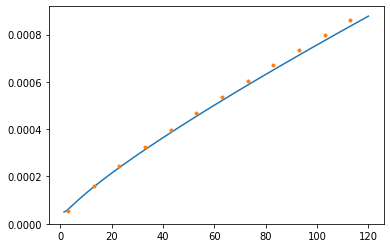

In [23]:
# N sweep
N_range = np.linspace(1.5, 120, 256)
V_range_slab = np.zeros_like(N_range, dtype=float)
V_range_bounded = np.zeros_like(N_range, dtype=float)
V_range_min = np.zeros_like(N_range, dtype=float)
V_range_max = np.zeros_like(N_range, dtype=float)

L_z = 40000
N_sample = 8
num_images = 100
eps = 0.0

for i, N in enumerate(N_range):
  a = 0.5 * L_z / (N-1)

  x_vec_on_bdry = np.linspace(-a, a, N_sample)
  z_vec_on_bdry = eps * L_z * np.ones_like(x_vec_on_bdry)
  # Build trapezoid quadrature covector
  integ_vec = np.ones_like(x_vec_on_bdry) * (x_vec_on_bdry[1] - x_vec_on_bdry[0])
  integ_vec[0] *= 0.5
  integ_vec[-1] *= 0.5

  # Evaluate potential diff
  potential_diff = 2 * U(x_vec_on_bdry, z_vec_on_bdry, num_images, a=a, L_z=L_z)
  # Evaluate bounded version
  lat_images = 3
  potential_diff_bounded = potential_diff.copy()
  for lat_idx in range(lat_images):
    potential_diff_bounded += 2 * (
      U(x_vec_on_bdry - 2 * L_z, z_vec_on_bdry, num_images, a, L_z)
      + U(x_vec_on_bdry + 2 * L_z, z_vec_on_bdry, num_images, a, L_z))

  V_range_slab[i] = np.dot(integ_vec, potential_diff)
  V_range_bounded[i] = np.dot(integ_vec, potential_diff_bounded)
  V_range_max[i] = potential_diff.max()
  V_range_min[i] = potential_diff.min()

# Import data from graph notebook
# gc_import = np.array([5.50000000e-05, 7.93133104e-05, 1.01281959e-04, 1.21715220e-04,
#        1.41088185e-04, 1.59673807e-04, 1.77642878e-04, 2.20545094e-04,
#        2.61330145e-04, 3.00571684e-04, 3.38614773e-04, 3.75687408e-04,
#        4.11950236e-04, 4.47521883e-04])
# gc_8way_import = np.array([9.79938358e-05, 1.49365022e-04, 1.95329757e-04, 2.38259408e-04,
#        2.79142758e-04, 3.18510769e-04, 3.56690367e-04, 4.48230785e-04,
#        5.35655813e-04, 6.20064354e-04, 7.02120532e-04, 7.82264999e-04,
#        8.60809362e-04, 9.37984427e-04])
# N_import = np.array([ 3,  5,  7,  9, 11, 13, 15, 20, 25, 30, 35, 40, 45, 50])

N_import, gc_import, = (np.array([  3,  13,  23,  33,  43,  53,  63,  73,  83,  93, 103, 113]),
 np.array([5.50000000e-05, 1.59673807e-04, 2.45226499e-04, 3.23524877e-04,
        3.97533948e-04, 4.68571746e-04, 5.37371324e-04, 6.04394152e-04,
        6.69954863e-04, 7.34280329e-04, 7.97541086e-04, 8.59869511e-04]))

# plt.plot(N_range, V_range_slab)
plt.plot(N_range, 1/V_range_min)
# plt.plot(N_range, 1/V_range_max)
# plt.plot(N_range, 1/V_range_bounded)
plt.plot(N_import, gc_import, '.')

plt.ylim(bottom=0)

Finally, the discrepancy may be due to mapping between the piecewise constant Neumann data and the entering node in the discrete setting. Note that the discrete setting maps naturally to the Dirichlet problem, since we set the potential in the graph Laplacian calculation. However, the Dirichlet problem is slightly more complicated since the unknown is inside the double-layer potential.

Finally, we remark that there is no limiting case in the continuous solution for $a / L_z \to 0$; the solution behaves as $\ln(r)$ near $(x, z) = (0, 0)$. As such, increasingly localized mass transfer is favoured by higher conductivities.

We choose the lowest potential surface (anything else is resistance ``internal" to the boundary effect). We can see this as three resistors in series: first, a resistor at the boundary to account for the difference in potential at $z = 0$ and $-a < x < a$. Then, the resistor with effective resistance that is of interest. Finally, a resistor at the opposing boundary to account for potential changes at the exit boundary. Thus, the effective resistance is best represented in this case using the minimum potential difference between the two "terminals."

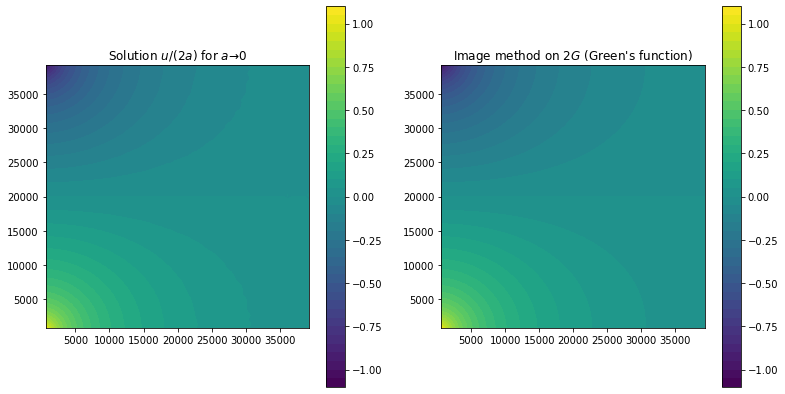

In [24]:
# Specific calculation
L_z = 40000
N = 30
eps = 1e-7
num_images = 20
N_sample = 100
# Compute finite aperture
a = L_z * 1e-12

# Evaluate field for plotting
x_viz_range = np.linspace(0, L_z, 64)[1:-1]
z_viz_range = np.linspace(0, L_z, 64)[1:-1]
mg_x, mg_z = np.meshgrid(x_viz_range, z_viz_range)

mg_u = U(mg_x, mg_z, num_images, a=a, L_z=L_z) # + U(mg_x - 2 * L_z, mg_z, 10, a=a, L_z=L_z)

plt.figure(figsize=(13,7))
plt.subplot(1,2,1)
plt.contourf(mg_x, mg_z, mg_u * (1/(2*a)), levels=50)
plt.title(r"Solution $u/(2a)$ for $a \to 0$")
plt.colorbar()
plt.gca().set_aspect("equal")

def log_grid(x, z, num_images:int, L_z=10.0):
  u = np.zeros(x.shape)
  next_sign = 1.0
  for img_idx in range(num_images):
    u += next_sign * (
      G(x, z, 0.0, (-img_idx)*L_z)
      - G(x, z, 0.0, (img_idx+1)*L_z))
    next_sign *= -1.0   
  return u

plt.subplot(1,2,2)
plt.contourf(mg_x, mg_z, 2 * log_grid(mg_x, mg_z, num_images, L_z=L_z), levels=50)
plt.title("Image method on $2G$ (Green's function)")
plt.colorbar()
plt.gca().set_aspect("equal")

# # Use symmetry to compute potential difference between boundaries; average over aperture
# x_vec_on_bdry = np.linspace(-a, a, N_sample)
# z_vec_on_bdry = eps * L_z * np.ones_like(x_vec_on_bdry)
# # Build trapezoid quadrature covector
# integ_vec = np.ones_like(x_vec_on_bdry) * (x_vec_on_bdry[1] - x_vec_on_bdry[0])
# integ_vec[0] *= 0.5
# integ_vec[-1] *= 0.5

# # Evaluate potential diff
# u_terminals_in = U(x_vec_on_bdry, z_vec_on_bdry, num_images, a=a, L_z=L_z)
# u_terminals_out = U(x_vec_on_bdry, L_z - z_vec_on_bdry, num_images, a=a, L_z=L_z)
# potential_diff = (u_terminals_in - u_terminals_out)
# # Compute average
# V_avg = np.dot(integ_vec, potential_diff) / (2 * a)

# plt.subplot(1,2,2)
# plt.plot(x_vec_on_bdry/a, potential_diff)
# plt.xlabel("x / a")
# plt.ylabel("Difference in averaged potential")

# plt.tight_layout()

# print(f"a/L = {a/L_z}")
# print(f"Average conductivity = {(2 * a / V_avg)}")

The factor of 2 on the Green's function can be seen as "folding" the energy into the domain. This is the same factor of $1/2$ that appears in the boundary integral representation.

### Notes

* Is the graph a different topology than continuum?
    * Seems not, should converge to continuum
* See Laplace-Beltrami operator
* Later: non-isotropic permeability from upscaling the graph network; directed and horizontal permeability; paper 2?

* Scale up graphs with iterative / laplacian solver
* Check integral representation on final continuum soln

### Legacy

In [ ]:
''' Legacy '''

def u_bdry(x, a):
  ''' u along boundary '''
  tm = np.abs(np.abs(x) - a)
  tp = np.abs(np.abs(x) + a)
  s1 = np.zeros_like(tm)
  np.log(tm, out=s1, where=tm>0)
  s1 = tm * (s1 - 1)
  s2 = tp * (np.log(tp) - 1)
  return 2 * -1.0/(2.0 * np.pi) * np.where(np.abs(x) < a, s2 + s1, s2 - s1)

def G(x, z, x0, z0):
  return -0.25 / np.pi * np.log((x-x0)**2 + (z-z0)**2)

def dGdn(x, z, x0, z0, normal_sign):
  # Compute distance and direction-cosine
  r = np.sqrt((x-x0)**2 + (z-z0)**2)
  dir_cos = (z - z0) / r
  return -0.5 * normal_sign / (np.pi * r) * dir_cos

def u_field(x, z, a=1.0, z0=0.0, x_inf=31.0, N_int=120, N_ext=120, normal_sign=1.0):
  ''' Reconstruct solution based on numerically integrating Green's representation '''

  # Construct integration meshes
  x0_int = np.linspace(-a, a, N_int)
  x0_ext_L = np.linspace(-x_inf, -a, N_ext)
  x0_ext_R = np.linspace(a, x_inf, N_ext)

  # Compute single-layer potential int(dudz G)
  quad_weights = np.full((x0_int.shape[0],), x0_int[1] - x0_int[0])
  quad_weights[0] *= 0.5
  quad_weights[1] *= 0.5
  SL = (G(x, z, x0_int, z0) * quad_weights).sum()

  # Compute double-layer potential int(u dGdz)
  DL = (dGdn(x, z, x0_int, z0, normal_sign) * u_bdry(x0_int, a) * quad_weights).sum()
  quad_weights = np.full((x0_ext_L.shape[0],), x0_ext_L[1] - x0_ext_L[0])
  quad_weights[0] *= 0.5
  quad_weights[1] *= 0.5
  DL += (dGdn(x, z, x0_ext_L, z0, normal_sign) * u_bdry(x0_ext_L, a) * quad_weights).sum()
  quad_weights = np.full((x0_ext_R.shape[0],), x0_ext_R[1] - x0_ext_R[0])
  quad_weights[0] *= 0.5
  quad_weights[1] *= 0.5
  DL += (dGdn(x, z, x0_ext_R, z0, normal_sign) * u_bdry(x0_ext_R, a) * quad_weights).sum()

  return 2 * (SL - DL)

def u_field_imaged(x, z, num_images:int, a=1.0, L_z=10.0, x_inf=31.0, N_int=120, N_ext=120):
  u = np.zeros((x.size,))
  next_sign = 1.0
  for img_idx in range(num_images):
    for i, (_x, _z) in enumerate(zip(x.ravel(), z.ravel())):    
      u[i] += next_sign * (
        u_field(_x, _z, a=a, z0=(-img_idx)*L_z, x_inf=x_inf, N_int=N_int, N_ext=N_ext, normal_sign=1.0)
        - u_field(_x, _z, a=a, z0=(img_idx+1)*L_z, x_inf=x_inf, N_int=N_int, N_ext=N_ext, normal_sign=-1.0)
      )
    next_sign *= -1.0
  return np.reshape(u, x.shape)

''' Testing (compute separately for each image) '''

x_viz_range = np.linspace(0, 10, 20)
z_viz_range = np.linspace(0, 10, 20, endpoint=False)[1:]
mg_x, mg_z = np.meshgrid(x_viz_range, z_viz_range)

u0 = np.empty((mg_x.size,))
u1 = np.empty((mg_x.size,))
u2 = np.empty((mg_x.size,))
Lz = 10.0
for i, (x, z) in enumerate(zip(mg_x.ravel(), mg_z.ravel())):
  u0[i] = (u_field(x, z, a=1.0, z0=0.0, x_inf=31.0, N_int=120, N_ext=120, normal_sign=1.0)
          - u_field(x, z, a=1.0, z0=Lz, x_inf=31.0, N_int=120, N_ext=120, normal_sign=-1.0))
  u1[i] = (-u_field(x, z, a=1.0, z0=-Lz, x_inf=31.0, N_int=120, N_ext=120, normal_sign=1.0)
          + u_field(x, z, a=1.0, z0=2*Lz, x_inf=31.0, N_int=120, N_ext=120, normal_sign=-1.0))
  u2[i] = (u_field(x, z, a=1.0, z0=-2*Lz, x_inf=31.0, N_int=120, N_ext=120, normal_sign=1.0)
          - u_field(x, z, a=1.0, z0=3*Lz, x_inf=31.0, N_int=120, N_ext=120, normal_sign=-1.0))
mg_u0 = np.reshape(u0, mg_x.shape)
mg_u1 = np.reshape(u1, mg_x.shape)
mg_u2 = np.reshape(u2, mg_x.shape)

plt.figure(figsize=(11,7))
plt.subplot(1,2,1)
plt.contourf(mg_x, mg_z, mg_u0 + mg_u1 + mg_u2, levels=100)
plt.title("Total field $u_0 + u_1 + u_2$")
plt.colorbar()
plt.gca().set_aspect("equal")
plt.subplot(1,2,2)
plt.contourf(mg_x, mg_z, mg_u1 + mg_u2, levels=100)
plt.title("Residual field $u_1 + u_2$")
plt.colorbar()
plt.gca().set_aspect("equal")

In [ ]:
def sample(x, z, b=31.0):
  ''' Reconstruct solution based on numerically integrating Green's representation.
   
  Sets "numerical infinity" to b '''
  # dudz G - u dGdz
  z0 = 0.0
  x0_int = np.linspace(-a, a, 120)
  x0_ext_L = np.linspace(-b, -a, 121)
  x0_ext_R = np.linspace(a, b, 121)

  # Compute single-layer potential int(dudz G)
  quad_weights = np.full((x0_int.shape[0],), x0_int[1] - x0_int[0])
  quad_weights[0] *= 0.5
  quad_weights[1] *= 0.5
  SL = (G(x, z, x0_int, z0) * quad_weights).sum()

  # Compute double-layer potential int(u dGdz)
  DL = (dGdn(x, z, x0_int, z0) * u_bdry(x0_int) * quad_weights).sum()
  quad_weights = np.full((x0_ext_L.shape[0],), x0_ext_L[1] - x0_ext_L[0])
  quad_weights[0] *= 0.5
  quad_weights[1] *= 0.5
  DL += (dGdn(x, z, x0_ext_L, z0) * u_bdry(x0_ext_L) * quad_weights).sum()
  quad_weights = np.full((x0_ext_R.shape[0],), x0_ext_R[1] - x0_ext_R[0])
  quad_weights[0] *= 0.5
  quad_weights[1] *= 0.5
  DL += (dGdn(x, z, x0_ext_R, z0) * u_bdry(x0_ext_R) * quad_weights).sum()

  return 1 * (SL - DL)

def G(x, z, x0, z0):
  return -0.25 / np.pi * np.log((x-x0)**2 + (z-z0)**2)

def dGdn(x, z, x0, z0):
  # Compute distance and direction-cosine
  r = np.sqrt((x-x0)**2 + (z-z0)**2)
  dir_cos = (z - z0) / r
  return -0.5 / (np.pi * r) * dir_cos

x_viz_range = np.linspace(0, 10, 100, endpoint=False)
z_viz_range = np.linspace(0, 10, 101)[1:]
mg_x, mg_z = np.meshgrid(x_viz_range, z_viz_range)

u = np.empty((mg_x.size,))
for i, (x, z) in enumerate(zip(mg_x.ravel(), mg_z.ravel())):
  u[i] = sample(x, z)
mg_u = np.reshape(u, mg_x.shape)

plt.contourf(mg_x, mg_z, mg_u, levels=100)
plt.gca().set_aspect("equal")

In [ ]:
import scipy.integrate
# Adaptive integration for computing imaged 

def u_bdry(x, a):
  ''' u along boundary '''
  tm = np.abs(np.abs(x) - a)
  tp = np.abs(np.abs(x) + a)
  s1 = np.zeros_like(tm)
  np.log(tm, out=s1, where=tm>0)
  # Compute t log(t) - t; note that when t == 0, the limit is zero
  s1 = tm * (s1 - 1)
  s2 = tp * (np.log(tp) - 1)
  return 2 * -1.0/(2.0 * np.pi) * np.where(np.abs(x) < a, s2 + s1, s2 - s1)

def G(x, z, x0, z0):
  return -0.25 / np.pi * np.log((x-x0)**2 + (z-z0)**2)

def dGdn(x, z, x0, z0, normal_sign):
  # Compute distance and direction-cosine
  r = np.sqrt((x-x0)**2 + (z-z0)**2)
  dir_cos = (z - z0) / r
  return -0.5 * normal_sign / (np.pi * r) * dir_cos

def u_field_quad(x, z, a=1.0, z0=0.0, nz_sign=1.0):
  ''' Reconstruct solution based on numerically integrating Green's representation '''
    # Vector of error estimates
  err_est = np.zeros((4,))
  # Compute single-layer potential int(dudz G)
  SL, err_est[0] = scipy.integrate.quad(lambda x0: G(x, z, x0, z0), -a, a)
  # Compute double-layer potential int(u dGdz)
  DL0, err_est[1] = scipy.integrate.quad(lambda x0: dGdn(x, z, x0, z0, nz_sign) * u_bdry(x0, a), -a, a)
  DL1, err_est[2] = scipy.integrate.quad(lambda x0: dGdn(x, z, x0, z0, nz_sign) * u_bdry(x0, a), a, np.inf)
  DL2, err_est[3] = scipy.integrate.quad(lambda x0: dGdn(x, z, x0, z0, nz_sign) * u_bdry(x0, a), -np.inf, -a)
  # Return u(x,z) and quadrature error estimate vector
  return SL - (DL0 + DL1 + DL2)

def U(x, z, num_images:int, a=1.0, L_z=10.0, backend='default', x_inf=1e12):
  # Array of error estimates
  # err_est = np.zeros((num_images, 4,))

  if backend == "default":
    u = np.zeros(x.shape)
    next_sign = 1.0
    for img_idx in range(num_images):
      u += next_sign * (
        SL_integral(x, z, (-img_idx)*L_z, a)
        - SL_integral(x, z, (img_idx+1)*L_z, a)
        - DL_int(x, z, (-img_idx)*L_z, a, 1.0, x_inf=x_inf)
        + DL_int(x, z, (img_idx+1)*L_z, a, -1.0, x_inf=x_inf)
        )
      next_sign *= -1.0   
    return u
  elif backend == "naive":
    ''' Quadrature for each term, then sum. '''
    u = np.zeros((x.size,))
    next_sign = 1.0
    for img_idx in range(num_images):
      for i, (_x, _z) in enumerate(zip(x.ravel(), z.ravel())):    
        u_field = next_sign * (
          u_field_quad(_x, _z, a=a, z0=(-img_idx)*L_z, nz_sign=1.0)
          - u_field_quad(_x, _z, a=a, z0=(img_idx+1)*L_z, nz_sign=-1.0)
        )
        u[i] += u_field
        # err_est[img_idx, :] = err
      next_sign *= -1.0
    return np.reshape(u, x.shape) #, err_est
  elif backend == "prestack":
    ''' Quadrature using presummed integrated. Faster than naive. '''
    u = np.zeros((x.size,))

    def SL_integrand(x, z, x0):
      next_sign = 1.0
      out = 0.0
      for img_idx in range(num_images):
        out += next_sign * (G(x, z, x0, (-img_idx)*L_z) - G(x, z, x0, (img_idx+1)*L_z))
        next_sign *= -1.0
      return out
    
    def DL_integrand(x, z, x0):
      next_sign = 1.0
      out = 0.0
      for img_idx in range(num_images):
        out += next_sign * (
          dGdn(x, z, x0, (-img_idx)*L_z, 1.0)
          - dGdn(x, z, x0, (img_idx+1)*L_z, -1.0)
        )  * u_bdry(x0, a)
        next_sign *= -1.0
      return out

    for i, (_x, _z) in enumerate(zip(x.ravel(), z.ravel())):    
      # Numerical quadrature
      SL = scipy.integrate.quad(lambda x0: SL_integrand(_x, _z, x0), -a, a)[0]
      DL = scipy.integrate.quad(lambda x0: DL_integrand(_x, _z, x0), -np.inf, np.inf)[0]
      u[i] = SL - DL

    return np.reshape(u, x.shape) #, err_est
  else:
    raise NotImplementedError(f"Unknown backend ``{backend}''; use default or prestack.")


''' Testing (compute separately for each image) '''

L_z = 5.0

x_viz_range = np.linspace(0, L_z, 32)[1:-1]
z_viz_range = np.linspace(0, L_z, 32)[1:-1]
mg_x, mg_z = np.meshgrid(x_viz_range, z_viz_range)

mg_u = U(mg_x, mg_z, 10, a=20.0, L_z=L_z, backend="default")

plt.figure(figsize=(11,7))
plt.contourf(mg_x, mg_z, mg_u, levels=100)
plt.colorbar()
plt.gca().set_aspect("equal")


In [ ]:
''' Limiting value for centerline potential '''

# Epsilon value near z = 0 to offset probe point
eps = 1e-14
# Compute limiting potential values at terminals
L_z = 10.0
a_range = L_z * np.logspace(-8, -2, 30)
a_range = L_z * np.geomspace(1/60.0, 1/2.0, 30)
# Allocate output vector
potential_diffs = np.zeros_like(a_range)

for i, a in enumerate(a_range):
  u_terminals = U(np.array([0, 0]), np.array([eps, L_z-eps]), 500, a=a, L_z=L_z)
  potential_diffs[i] = (u_terminals[0] - u_terminals[1])

plt.semilogx(a_range, potential_diffs / a, 'k.-')
plt.xlabel("$a / L$")
plt.ylabel("$\Delta u / (a \log a)$")

In [ ]:
''' Lateral images '''
# def U_finite(x, z, num_images:int, lat_images=3, a=1.0, L_z=10.0, backend='default'):
#   # Array of error estimates
#   # err_est = np.zeros((num_images, 4,))
#     u = np.zeros(x.shape)
#     lat_sign = 1.0
#     for lat_idx in range(lat_images):
#       next_sign = 1.0
#       for img_idx in range(num_images):
#         if lat_idx == 0:
#           # Prime image
#           u += next_sign * (
#             SL_integral(x, z, (-img_idx)*L_z, a)
#             - SL_integral(x, z, (img_idx+1)*L_z, a)
#             - DL_int(x, z, (-img_idx)*L_z, a, 1.0)
#             + DL_int(x, z, (img_idx+1)*L_z, a, -1.0)
#             )
#         else:
#            # Double image
#           u += next_sign * (
#             SL_integral(-x + 1.5*L_z -, z, (-img_idx)*L_z, a)
#             - SL_integral(x + 1.5*lat_idx*L_z, z, (img_idx+1)*L_z, a)
#             - DL_int(x + 1.5*lat_idx*L_z, z, (-img_idx)*L_z, a, 1.0)
#             + DL_int(x + 3*lat_idx*L_z, z, (img_idx+1)*L_z, a, -1.0)
#             + SL_integral(x - 3*lat_idx*L_z, z, (-img_idx)*L_z, a)
#             - SL_integral(x - 3*lat_idx*L_z, z, (img_idx+1)*L_z, a)
#             - DL_int(x - 3*lat_idx*L_z, z, (-img_idx)*L_z, a, 1.0)
#             + DL_int(x - 3*lat_idx*L_z, z, (img_idx+1)*L_z, a, -1.0)
#             )
#         next_sign *= -1.0   
#     return u


In [ ]:
''' Boundary condition verification for image solution '''

z0 = 0.0
z = 0.5
L_z = 2.0
a = 1.0

x_range = np.linspace(0.0,3*a,100)
eps_z = 1e-7
z_range = np.full_like(x_range, eps_z)

dUdy_estimate = (
  U(x_range, z_range, 20, a, L_z,)
  - U(x_range, 0.5 * z_range, 20, a, L_z,)) / (0.5 * eps_z)

plt.subplot(1,2,1)
plt.plot(x_range, U(x_range, z_range, 20, a, L_z,))
plt.xlabel(r"$x$")
plt.ylabel(r"$U$")
plt.subplot(1,2,2)
plt.plot(x_range, dUdy_estimate)
plt.xlabel(r"$x$")
plt.ylabel(r"$\partial U / \partial z$")
print("Below: method of images near boundary")

In [ ]:
''' Estimate error of numerically evaluated Laplacian on solution
This doesn't say much, since the error will be reflecting primarily the
discretization of the Laplacian used for this verification.
'''

# Evaluate field for plotting
_N = 256
x_viz_range = np.linspace(0, L_z, _N)[1:-1]
z_viz_range = np.linspace(0, L_z, _N)[1:-1]
mg_x, mg_z = np.meshgrid(x_viz_range, z_viz_range)

# Single
mg_u = SL_integral(mg_x, mg_z, 0.0, a) - DL_int(mg_x, mg_z, 0.0, a, 1.0, x_inf=x_inf)

plt.figure(figsize=(14,7))
plt.subplot(1,2,1)
plt.contourf(mg_x, mg_z, mg_u, levels=50)
plt.title(r"$u$")
plt.colorbar()
plt.gca().set_aspect("equal")

Lu = 0.25 * (mg_u[2:,1:-1] + mg_u[:-2,1:-1]
             + mg_u[1:-1,2:] + mg_u[1:-1,:-2]
             - 4 * mg_u[1:-1,1:-1])
dx = (mg_x[0,1] - mg_x[0,0])
dz = (mg_z[1,0] - mg_z[0,0])
plt.subplot(1,2,2)
plt.contourf(mg_x[1:-1,1:-1], mg_z[1:-1,1:-1], np.log10(np.abs(Lu / dx / dz)), levels=50)
plt.colorbar()
plt.gca().set_aspect("equal")
plt.title(r"$log_{10} |\nabla^2 u|$")

np.linalg.norm(Lu, ord="fro")